## Python Generation of Kinematics 

In [5]:
#1 

import numpy as np 
import sympy as sp 
import scipy 

l1 = sp.Symbol('l1')
l2 = sp.Symbol('l2')
theta1 = sp.Symbol('theta1')
theta2 = sp.Symbol('theta2')
l1
l2
theta1
theta2

#2 
t = sp.Symbol('t')
theta1 = sp.Function('theta1')(t)
theta2 = sp.Function('theta2')(t)

def TransformationMatrix(x,y,theta):
   
    updated_matrix = sp.Matrix([
        [sp.cos(theta), -sp.sin(theta), x],
        [sp.sin(theta), sp.cos(theta), y], 
        [0, 0, 1 ],
    ])
    return updated_matrix

#3 
T01 = TransformationMatrix(l1*sp.cos(theta1), l1*sp.sin(theta1), theta1)
T12 = TransformationMatrix(l2*sp.cos(theta2), l2*sp.sin(theta2), theta2)
T02 = T01 @ T12 
T01.simplify()
T02.simplify()

#4 

T01_dot = T01.diff(t)
T02_dot = T02.diff(t)

def inv(T):
    R = T[0:2, 0:2]
    p = T[0:2, 2]

    T_inv = sp.Matrix.zeros(3,3)
    T_inv[0:2, 0:2] = R.T 
    T_inv[0:2, 2] = -R.T * p 
    return T_inv 

Vb1 = inv(T01) @ T01_dot 
Vb2 = inv(T02) @ T02_dot 

Vb1 = sp.Matrix([Vb1[1,0], Vb1[0,2], Vb1[1,2]])
Vb2 = sp.Matrix([Vb2[1,0], Vb2[0,2], Vb2[1,2]])

Vb1.simplify()
Vb2.simplify()
#print(Vb1)
#print(Vb2)

#5 
q_dot = sp.Matrix([theta1.diff(t), theta2.diff(t)])
Jb1 = Vb1.jacobian(q_dot)
Jb2 = Vb2.jacobian(q_dot)


Jb1.simplify()
Jb2.simplify()


#6
worldP = sp.lambdify([theta1, theta2,l1,l2], [l1*sp.cos(theta1) + l2*sp.cos(theta1 + theta2), l1*sp.sin(theta1) + l2*sp.sin(theta1 + theta2)])
worldP(0,0,1,1)

desired_solution = scipy.optimize.minimize(lambda x: np.linalg.norm(worldP(x[0],x[1], 2,2) - np.array([2,1])), [0.5,1], tol=1e-5)

# testing area 


In [10]:
T01

Matrix([
[cos(theta1(t)), -sin(theta1(t)), l1*cos(theta1(t))],
[sin(theta1(t)),  cos(theta1(t)), l1*sin(theta1(t))],
[             0,               0,                 1]])

In [11]:
T02

Matrix([
[cos(theta1(t) + theta2(t)), -sin(theta1(t) + theta2(t)), l1*cos(theta1(t)) + l2*cos(theta1(t) + theta2(t))],
[sin(theta1(t) + theta2(t)),  cos(theta1(t) + theta2(t)), l1*sin(theta1(t)) + l2*sin(theta1(t) + theta2(t))],
[                         0,                           0,                                                 1]])

In [12]:
Vb1

Matrix([
[   Derivative(theta1(t), t)],
[                          0],
[l1*Derivative(theta1(t), t)]])

In [13]:
Vb2

Matrix([
[                                                   Derivative(theta1(t), t) + Derivative(theta2(t), t)],
[                                                            l1*sin(theta2(t))*Derivative(theta1(t), t)],
[l1*cos(theta2(t))*Derivative(theta1(t), t) + l2*Derivative(theta1(t), t) + l2*Derivative(theta2(t), t)]])

In [14]:
Jb1

Matrix([
[ 1, 0],
[ 0, 0],
[l1, 0]])

In [15]:
Jb2

Matrix([
[                     1,  1],
[     l1*sin(theta2(t)),  0],
[l1*cos(theta2(t)) + l2, l2]])

In [16]:
desired_solution

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 5.2690491034531075e-09
        x: [-5.139e-01  1.955e+00]
      nit: 22
      jac: [ 1.595e+00  1.670e+00]
 hess_inv: [[ 1.259e-08 -2.314e-08]
            [-2.314e-08  7.829e-08]]
     nfev: 239
     njev: 76

# Exploring properties of rotations and transformations in Python

matrix 1 : [[ 0.1643571  -0.33058705 -0.92935405]
 [ 0.97084026 -0.11247578  0.21170353]
 [-0.17451627 -0.93704931  0.30246102]]  
matrix 2 : [[ 0.78237864  0.50175656  0.36894989]
 [-0.61672814  0.70670932  0.34671073]
 [-0.08677594 -0.49880085  0.86236167]]  
matrix 3 : [[ 0.76237387  0.0937541  -0.6403095 ]
 [-0.51650129  0.68427809 -0.5147717 ]
 [ 0.38988781  0.72316918  0.57009985]]  
matrix 4 : [[-0.58012091 -0.79968919 -0.15478028]
 [ 0.28477468 -0.37715731  0.88128074]
 [-0.76312719  0.46717188  0.44652808]]  
matrix 5 : [[-0.92094606  0.36103076 -0.14668043]
 [ 0.35491142  0.6216331  -0.6982909 ]
 [-0.16092309 -0.69514681 -0.70062449]]  
matrix 6 : [[ 0.67300413  0.67816994 -0.29521343]
 [ 0.73029715 -0.54604477  0.41048895]
 [ 0.11718152 -0.49185429 -0.86275596]]  
matrix 7 : [[ 0.40961124  0.69835332 -0.58695934]
 [-0.03025165  0.65345656  0.75635928]
 [ 0.91175845 -0.29205678  0.28878949]]  
matrix 8 : [[ 0.92564397 -0.18249564 -0.33147939]
 [ 0.29064287  0.90384216  0.3140

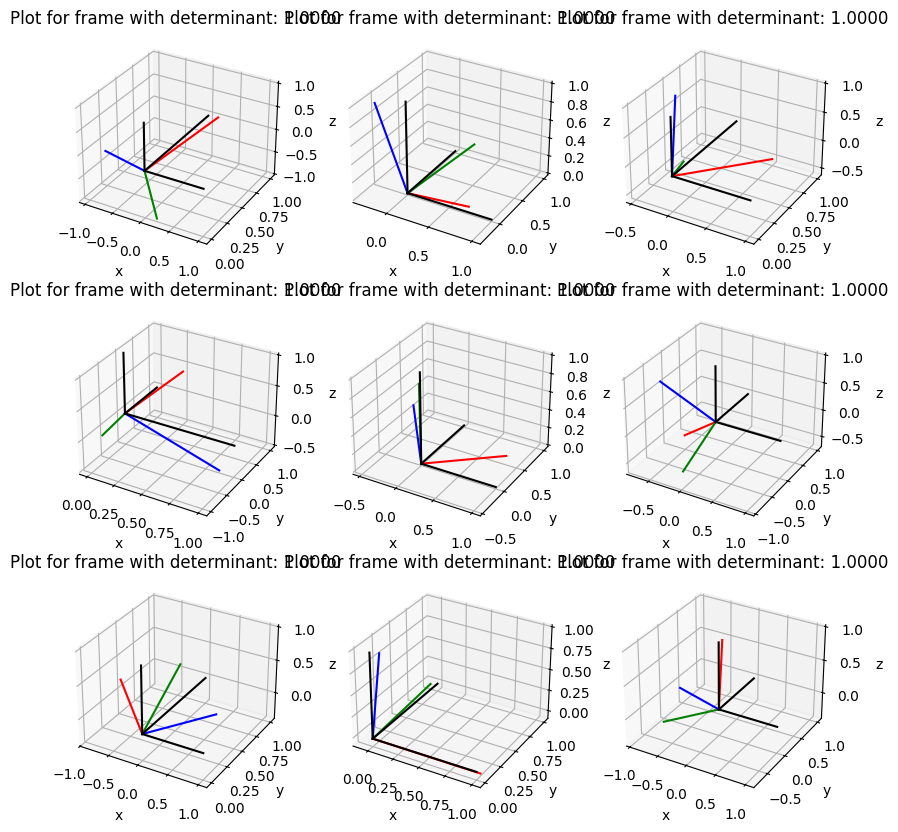

In [18]:
#1 
import matplotlib.pyplot as plt
#a 
def RandomMatrices():
    n = np.random.uniform(-5, 5, 3)
    n = n/np.linalg.norm(n) 
    theta = np.random.uniform(0,2*np.pi)

    nx,ny,nz = n 
    n_skew = np.array([
        [0, -nz, ny],
        [nz, 0, -nx],
        [-ny, nx, 0]
        ])

    rotation_matrix = np.eye(3) + np.sin(theta) * n_skew + (1-np.cos(theta)) * (n_skew @ n_skew)
    return rotation_matrix

#b 
rot_list = []
for i in range(9):
    rot_list.append(RandomMatrices())
    print("matrix", i+1, ":", rot_list[i], " ")

det = []
for j in range(len(rot_list)):
    det.append(np.linalg.det(rot_list[j]))
    print("matrix", j+1, "determinant:", det[j], " " )

#c 
def frame_plot(R,ax):
    ax.plot([0, R[0,0]], [0, R[1,0]], [0, R[2,0]], 'r')
    ax.plot([0, R[0,1]], [0, R[1,1]], [0, R[2,1]], 'g')
    ax.plot([0, R[0,2]], [0, R[1,2]], [0, R[2,2]], 'b')

    ax.plot([0,1], [0,0], [0,0], 'black')
    ax.plot([0,0], [0,1], [0,0], 'black')
    ax.plot([0,0], [0,0], [0,1], 'black')

fig = plt.figure(figsize=(10,10))

for i in range(9):
    random_matrix = RandomMatrices()
    determinant = np.linalg.det(random_matrix)
    ax = fig.add_subplot(3,3,i+1,projection = '3d')
    frame_plot(random_matrix, ax)
    ax.set_title(f"Plot for frame with determinant: {determinant:.4f}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')


Text(0.5, 0, 'z')

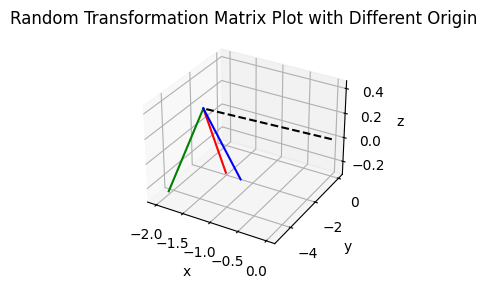

In [19]:

#2
#a
def origin_and_coord_frame(T,ax):
    origin_x, origin_y, origin_z = T[0:-1,-1]
    ax.plot([0, origin_x], [0, origin_y], [0,origin_z], 'black',linestyle='--')

    R = T[0:3, 0:3]
    ax.plot([origin_x, origin_x + R[0,0]], [origin_y, origin_y + R[1,0]], [origin_z, origin_z + R[2,0]], 'r')
    ax.plot([origin_x, origin_x + R[0,1]], [origin_y, origin_y + R[1,1]], [origin_z, origin_z + R[2,1]], 'g')
    ax.plot([origin_x, origin_x + R[0,2]], [origin_y, origin_y + R[1,2]], [origin_z, origin_z + R[2,2]] , 'b')

fig2 = plt.figure(figsize=(10,10))
T = np.eye(4) 
R = RandomMatrices()
T[0:3,0:3] = R 
p = np.random.uniform(-5, 5, 3) 
T[0:3, 3] = p 

ax = fig2.add_subplot(3, 3, 1, projection='3d')
origin_and_coord_frame(T, ax)
ax.set_title(f"Random Transformation Matrix Plot with Different Origin")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')



In [9]:
#2b
p_new = np.random.uniform(-5, 5, 3) 
p_new_norm = np.linalg.norm(p_new)
p_new_2 = np.append(p_new, 0)

p_transformed = T @ p_new_2
p_transformed = p_transformed[0:3]
p_transformed_norm = np.linalg.norm(p_transformed)

print(f'Initial vector: {p_new}')
print(f'Initial length: {p_new_norm}')
print(f'Final vector: {p_transformed}')
print(f'Final length: {p_transformed_norm}')

Initial vector: [ 0.17669291 -2.32161193 -1.43885454]
Initial length: 2.7370430633196245
Final vector: [ 1.44456739 -2.30855555  0.27422808]
Final length: 2.7370430633196245
